# **Import Libraries**

In [1]:
%matplotlib inline
import os
import cv2
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# **Data Load & Preprocessing**

In [2]:
data = []
labels = []
class_names = ['28', '29', 'Basmati', 'Chinipata', 'Miniket']
IMG_SIZE = (224, 224)

for label in class_names:
    folder = f'D:\Rice_Detection\Data_New\{label}'
    for img_file in os.listdir(folder):
        img_path = os.path.join(folder, img_file)
        img = cv2.imread(img_path)
        img = cv2.resize(img, IMG_SIZE)
        img = img / 255.0  # নরমালাইজেশন
        data.append(img)
        labels.append(class_names.index(label))

data = np.array(data)
labels = np.array(labels)

# **Training & Testing Data Split**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# **CNN Model Creation**

In [4]:
model = Sequential([
    Input(shape=(224, 224, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

# **Model Compile**

In [5]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# **Data Augmentation**

In [6]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)
datagen.fit(X_train)

# **Training Data**

In [7]:
history = model.fit(datagen.flow(X_train, y_train, batch_size=32), 
                    epochs=10, 
                    validation_data=(X_test, y_test))

Epoch 1/10


C:\Users\rony\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


126/126 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.3982 - loss: 1.2975 - val_accuracy: 0.8214 - val_loss: 0.6284
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.6944 - loss: 0.7452 - val_accuracy: 0.9028 - val_loss: 0.3330
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.7884 - loss: 0.5391 - val_accuracy: 0.8998 - val_loss: 0.2819
Epoch 4/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.8210 - loss: 0.4253 - val_accuracy: 0.8720 - val_loss: 0.3266
Epoch 5/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.8300 - loss: 0.4235 - val_accuracy: 0.9127 - val_loss: 0.2333
Epoch 6/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.8326 - loss: 0.4216 - val_accuracy: 0.8562 - val_loss: 0.3660
Epoch 7/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 128s 980ms/step - accuracy: 0.8529 - loss: 0.3728 - val_accuracy: 0.9157 - val_loss: 0.2248
Epoch 8/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 127s 980ms/step - accuracy: 0.8710 - loss: 0.3305 - val_accuracy:

# **Save Model**

In [8]:
model.save('rice_cnn_model.h5')

# **Accuracy**

In [9]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 226ms/step - accuracy: 0.8694 - loss: 0.2667
Test Accuracy: 88.29%


# **Accuracy Graph**

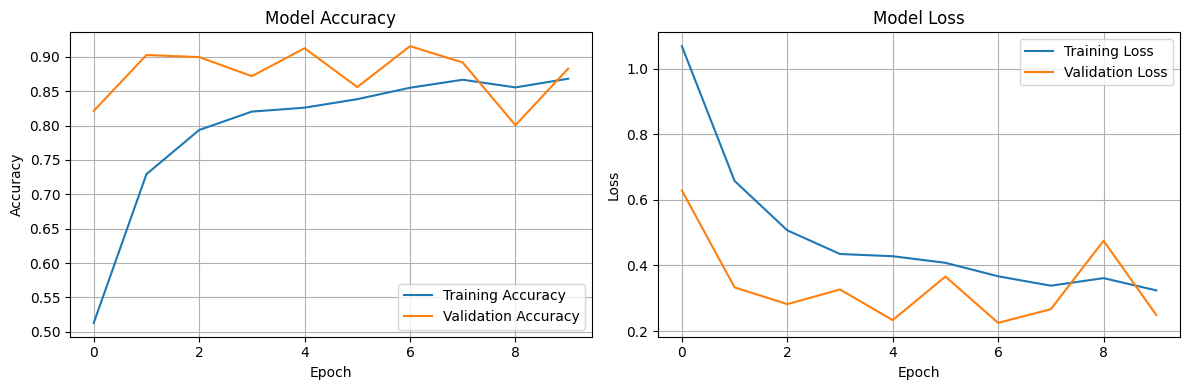

In [10]:
# Accuracy এবং Loss গ্রাফ
def plot_training_history(history):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
    
plot_training_history(history)

# **Confusion Matrix**

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 217ms/step


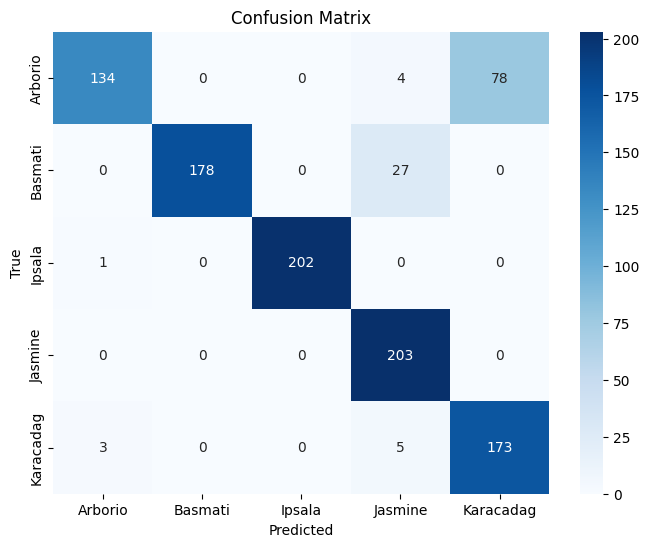

In [11]:
# Confusion Matrix
def plot_confusion_matrix(model, X_test, y_test, class_names):
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    cm = confusion_matrix(y_test, y_pred_classes)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

plot_confusion_matrix(model, X_test, y_test, class_names)

# **Classification Report**

In [13]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, target_names=class_names))

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 185ms/step

Classification Report:
              precision    recall  f1-score   support

     Arborio       0.97      0.62      0.76       216
     Basmati       1.00      0.87      0.93       205
      Ipsala       1.00      1.00      1.00       203
     Jasmine       0.85      1.00      0.92       203
   Karacadag       0.69      0.96      0.80       181

    accuracy                           0.88      1008
   macro avg       0.90      0.89      0.88      1008
weighted avg       0.91      0.88      0.88      1008

